# Random Forest Model
**Michael Maldonado**

### Importing Libraries

In [223]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import plot_roc_curve
from sklearn.metrics import accuracy_score, classification_report
import talib as ta

# If talib is not installed, uncomment and run
# !pip install talib-binary

### Loading data into dataframe

In [224]:
data = pd.read_csv("Data/ETFs/qqq.us.txt", delimiter = ",")
data = data.drop(columns = ["OpenInt"])
data["Date"] = pd.to_datetime(data["Date"])
data = data.set_index("Date")

data.head(5)

,Open,High,Low,Close,Volume
Date,,,,,
1999-03-10,45.722,45.750,44.967,45.665,11700414
1999-03-11,45.994,46.260,44.988,45.880,21670048
1999-03-12,45.721,45.749,44.406,44.770,19553768
1999-03-15,45.101,46.103,44.625,46.052,14245348
1999-03-16,46.253,46.643,45.749,46.447,10971066


Text(0.5, 1.0, 'NASDAQ: QQQ')

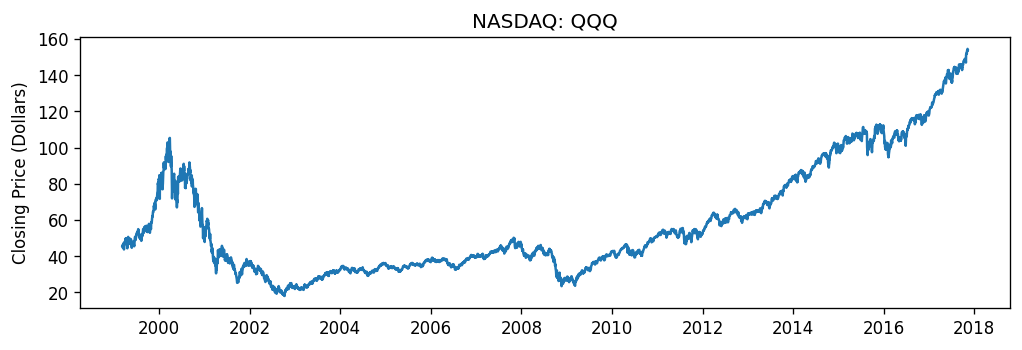

In [225]:
fig = plt.figure(dpi = 120, figsize= (10, 3))
ax = fig.add_subplot(1, 1, 1)
ax.plot(data["Close"])
ax.set_ylabel("Closing Price (Dollars)")
ax.set_title("NASDAQ: QQQ")

### Adding indicators to dataset

In [226]:
# RSI
data["RSI"] = ta.RSI(data["Close"].to_numpy())

# Stochastic Oscillator Slow
data["STOCH"] = ta.STOCH(data["High"].to_numpy(), 
                          data["Low"].to_numpy(), 
                          data["Close"].to_numpy())[0]

# Williams Percent Range
data["WILLR"] = ta.WILLR(data["High"].to_numpy(), 
                          data["Low"].to_numpy(), 
                          data["Close"].to_numpy())

# Moving Average Convergence/Divergence
data["MACD"] = ta.MACD(data["Close"].to_numpy())[0]

# Price Rate of Change
data["PROC"] = data['Close'].transform(lambda x: x.pct_change(periods = 9))

# On Balance Volume
data["OBV"] = ta.OBV(data["Close"].to_numpy(), data["Volume"].to_numpy(np.double))

# Average Directional Movement Index
data["ADX"] = ta.ADX(data["High"].to_numpy(), 
                     data["Low"].to_numpy(), 
                     data["Close"].to_numpy())

# Aroon Oscillator
data["AROON"] = ta.AROONOSC(data["High"].to_numpy(), data["Low"].to_numpy())

data.head(5)

,Open,High,Low,Close,Volume,RSI,STOCH,WILLR,MACD,PROC,OBV,ADX,AROON
Date,,,,,,,,,,,,,
1999-03-10,45.722,45.750,44.967,45.665,11700414,NaN,NaN,NaN,NaN,NaN,11700414.0,NaN,NaN
1999-03-11,45.994,46.260,44.988,45.880,21670048,NaN,NaN,NaN,NaN,NaN,33370462.0,NaN,NaN
1999-03-12,45.721,45.749,44.406,44.770,19553768,NaN,NaN,NaN,NaN,NaN,13816694.0,NaN,NaN
1999-03-15,45.101,46.103,44.625,46.052,14245348,NaN,NaN,NaN,NaN,NaN,28062042.0,NaN,NaN
1999-03-16,46.253,46.643,45.749,46.447,10971066,NaN,NaN,NaN,NaN,NaN,39033108.0,NaN,NaN


### Cleaning dataset

In [227]:
# Creating column for prediction
data["Prediction"] = data["Close"].transform(lambda x: (x.shift(1) < x) * 1)

# Dropping NaN values
print(f"Before NaN Drop: ROW:{data.shape[0]}, COL:{data.shape[1]}")
data = data.dropna()
print(f"After NaN Drop: ROW:{data.shape[0]}, COL:{data.shape[1]}")

data.head(5)

Before NaN Drop: ROW:4701, COL:14
After NaN Drop: ROW:4668, COL:14


,Open,High,Low,Close,Volume,RSI,STOCH,WILLR,MACD,PROC,OBV,ADX,AROON,Prediction
Date,,,,,,,,,,,,,,
1999-04-27,50.973,51.224,49.195,49.830,36863308,57.811022,88.722097,-18.475812,0.920327,0.055050,-10969163.0,20.127568,35.714286,0
1999-04-28,49.413,49.575,47.908,48.121,17167936,51.259834,61.637865,-41.126574,0.819158,0.005264,-28137099.0,18.826879,35.714286,0
1999-04-29,47.893,48.173,46.721,47.726,42827866,49.853638,37.439706,-46.361829,0.699050,0.026918,-70964965.0,18.296637,35.714286,0
1999-04-30,48.402,48.652,46.331,48.040,34208333,51.004290,23.336489,-42.200133,0.622030,0.084694,-36756632.0,17.483322,35.714286,1
1999-05-03,47.896,48.090,46.984,47.782,24847266,49.989312,28.966837,-45.619616,0.534017,0.054883,-61603898.0,16.728100,35.714286,0


### Splitting dataset and Training model

In [236]:
# Split into training and testing datasets
x_train, x_test, y_train, y_test = train_test_split(data[["RSI", "STOCH", "WILLR", 
                                                          "MACD", "PROC", "OBV", "ADX", "AROON"]], 
                                                    data["Prediction"], 
                                                    random_state = 0)
# Create a Random Forest Classifier
classifier = RandomForestClassifier(n_estimators = 100, oob_score = True, criterion = "gini", random_state = 0)

# Fit the data to the model
classifier.fit(x_train, y_train)

# Make predictions
y_pred = classifier.predict(x_test)

# Print the Accuracy of the model
print(f"Accuracy (%): {accuracy_score(y_test, y_pred, normalize = True) * 100.0}")

Accuracy (%): 77.12082262210797
